# Gradient Descent for Linear Regression

# Goal
In this lab, I will automate the process of finding the values of w and b using gradient descent, instead of guessing them manually.

In [1]:
import numpy as np
import math,copy
import matplotlib.pyplot as plt

## Problem Statement

Same two data points as before - a house with 1000 sqft sold for $300,000, and a house with 2000 sqft sold for $500,000.

In [15]:
x_train = np.array([1.0,1.5,2.0])
y_train = np.array([300.0,410.0,500.0])

### Compute Cost
This was developed in the last lab. We'll need it again here for gradient descent.

In [16]:
def compute_cost(x,y,w,b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w*x[i]+b
        cost+= (f_wb-y[i])**2
    total_cost = 1/(2*m)*cost
    return total_cost

### compute_gradient
This function calculates the gradient — the slope of the cost function with respect to w and b — which tells gradient descent which direction to move.

In [17]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w*x[i]+b
        dj_dw_i = (f_wb-y[i])*x[i]
        dj_db_i = (f_wb-y[i])
        dj_dw+= dj_dw_i
        dj_db+= dj_db_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw,dj_db
        
        
    

### Checking the gradient
Let's compute the gradient at w=0, b=0 to see which direction gradient descent should move.

In [18]:
w_test = 0
b_test = 0
dj_dw_result,dj_db_result = compute_gradient(x_train,y_train,w_test,b_test)
print(f"dj_dw at w=0, b=0: {dj_dw_result}")
print(f"dj_db at w=0, b=0: {dj_db_result}")
    

dj_dw at w=0, b=0: -638.3333333333334
dj_db at w=0, b=0: -403.3333333333333


### Gradient Descent
This function repeatedly calls compute_gradient and updates w and b, gradually reducing the cost until it converges on the best values.


In [19]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    j_history = []
    p_history = []
    w = w_in
    b = b_in
    
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        
        b = b - alpha * dj_db
        w = w - alpha * dj_dw
        
        j_history.append(cost_function(x, y, w, b))
        p_history.append([w, b])
        
        if i % 1000 == 0:
            print("Iteration", i, "Cost:", j_history[-1], "w:", w, "b:", b)
    
    return w, b, j_history, p_history
    

### Running Gradient Descent
Now let's actually use gradient_descent to find the best w and b automatically.

In [20]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2

w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration 0 Cost: 79077.85005787035 w: 6.383333333333334 b: 4.033333333333333
Iteration 1000 Cost: 14.699724285302361 w: 193.55465254738192 b: 113.50481823245697
Iteration 2000 Cost: 12.444294319823571 w: 196.07148941136012 b: 109.53296592446209
Iteration 3000 Cost: 11.606393656684917 w: 197.6055293281687 b: 107.11207799511799
Iteration 4000 Cost: 11.2951104281943 w: 198.5405436312582 b: 105.63652001562113
Iteration 5000 Cost: 11.179467545210487 w: 199.110445194707 b: 104.73715110041209
Iteration 6000 Cost: 11.136505781900375 w: 199.4578065034571 b: 104.18897579528465
Iteration 7000 Cost: 11.12054532623656 w: 199.66952706461228 b: 103.85485688137736
Iteration 8000 Cost: 11.114615957296046 w: 199.79857308927507 b: 103.65120770640279
Iteration 9000 Cost: 11.112413174570161 w: 199.87722806917134 b: 103.52708128092509
(w,b) found by gradient descent: (199.9251,103.4515)


### Cost versus iterations of gradient descent
A plot of cost vs iterations shows whether training is actually working — cost should steadily decrease.

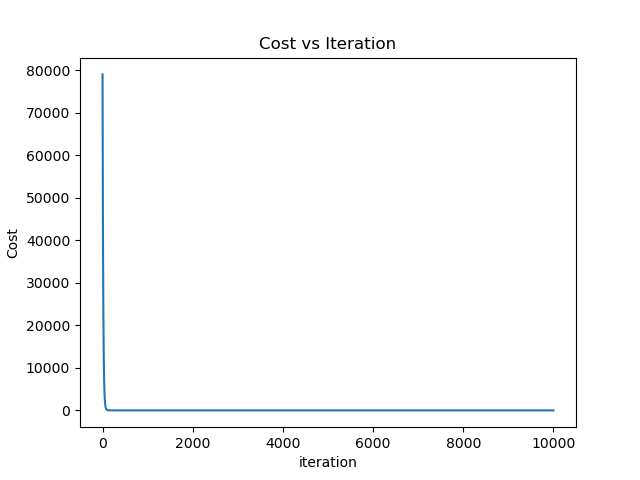

In [21]:
plt.figure()
plt.plot(J_hist)
plt.xlabel("iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.savefig("cost_vs_iteration.png")
plt.close()

from IPython.display import Image
Image("cost_vs_iteration.png")